# 08b — MD Extensions: BSA Over Time & Interface RMSD

**Purpose:** Compute trajectory-level metrics not included in the core notebook 08 analysis — specifically buried surface area (BSA) over time and interface RMSD (binder displacement relative to PD-L1 after target-aligned superposition).

**Dependencies:**
- Completed notebook 08 outputs (equilibrated PDBs, production DCD trajectories)
- `md_manifest.csv` from notebook 08
- MDTraj (trajectory loading, alignment, RMSD, SASA)

**Compute:** ~5–10 min per system on Colab CPU (no GPU required).

**Key implementation detail:** DCD trajectories from NPT simulations have periodic boundary conditions. The binder and target can drift into different periodic images, making raw Cartesian distances meaningless (80+ Å "distances" between bound partners). Before computing BSA or RMSD, we must re-image the trajectory to place all protein atoms in the same periodic box.

**Outputs per design:**
- `bsa_over_time.csv` — BSA at each trajectory frame
- `interface_rmsd.csv` — interface RMSD at each trajectory frame
- `bsa_interface_summary.json` — summary statistics


In [1]:
# ============================================================
# Cell 0 — dependency setup
# ============================================================

import sys
import subprocess
import importlib.util

def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pip_name]
        )
    else:
        print(f"{import_name} already installed.")

ensure_package("mdtraj", "mdtraj")
ensure_package("Bio", "biopython")

Installing mdtraj...
Installing biopython...


In [2]:
# ============================================================
# Cell 1 — Setup and imports
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import mdtraj as md

DRIVE_BASE = Path("/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design")
RESULTS_DIR = DRIVE_BASE / "data/results/md_simulations_threaded_complexes"
MANIFEST_CSV = RESULTS_DIR / "md_manifest.csv"

FORCE = True  # Set True to recompute

manifest = pd.read_csv(MANIFEST_CSV)
print(f"Loaded manifest: {len(manifest)} systems")
for _, row in manifest.iterrows():
    print(f"  {row['design_name']}  binder_chain={row['binder_chain']}  target_chain={row['target_chain']}")


Mounted at /content/drive
Loaded manifest: 3 systems
  len70_clusterA_noise05__design_19_0_rank0  binder_chain=B  target_chain=A
  len70_distributed_noise0__design_17_0_rank1  binder_chain=B  target_chain=A
  len70_clusterB_noise0__design_19_0_rank1  binder_chain=B  target_chain=A


In [3]:
# ============================================================
# Cell 2 — Load and re-image a trajectory (diagnostic cell)
# ============================================================
# Purpose: Verify that re-imaging fixes the PBC artifact
#          before running the full analysis
# ============================================================

row = manifest.iloc[0]
design_name = row['design_name']
traj_dcd = Path(row['traj_dcd'])
top_pdb = Path(row['equilibrated_pdb'])

print(f"Design: {design_name}")
print(f"Loading trajectory...")

traj = md.load(str(traj_dcd), top=str(top_pdb))
print(f"  Raw trajectory: {traj.n_frames} frames, {traj.n_atoms} atoms")
print(f"  Unitcell lengths (frame 0): {traj.unitcell_lengths[0]} nm")

# Strip to protein
protein_idx = traj.topology.select("protein")
traj_protein = traj.atom_slice(protein_idx)

# Check chain info
chains = list(traj_protein.topology.chains)
for i, c in enumerate(chains):
    print(f"  Chain {i}: {c.n_residues} residues, {c.n_atoms} atoms")

# Identify chains
binder_chain_idx = None
target_chain_idx = None
for i, c in enumerate(chains):
    if c.n_residues <= 75:
        binder_chain_idx = i
    else:
        target_chain_idx = i

top = traj_protein.topology
binder_ca = top.select(f"chainid {binder_chain_idx} and name CA")
target_ca = top.select(f"chainid {target_chain_idx} and name CA")

# Check distances BEFORE re-imaging
binder_com_before = traj_protein.xyz[:, binder_ca, :].mean(axis=1)  # (n_frames, 3)
target_com_before = traj_protein.xyz[:, target_ca, :].mean(axis=1)
com_dist_before = np.sqrt(((binder_com_before - target_com_before)**2).sum(axis=1)) * 10  # nm -> A

print(f"\nBEFORE re-imaging:")
print(f"  Binder-Target COM distance: mean={com_dist_before.mean():.1f} A, range=[{com_dist_before.min():.1f}, {com_dist_before.max():.1f}]")
if com_dist_before.mean() > 30:
    print(f"  ⚠ COM distance >> 30 A — PBC artifact confirmed!")

# Re-image: center on the target, bring everything into the same box
# MDTraj's image_molecules works on the full solvated trajectory
print(f"\nRe-imaging full trajectory (center on protein)...")
protein_atom_objects = [traj.topology.atom(i) for i in protein_idx]
traj_reimaged = traj.image_molecules(inplace=False, anchor_molecules=[set(protein_atom_objects)])
traj_protein_reimaged = traj_reimaged.atom_slice(protein_idx)

binder_com_after = traj_protein_reimaged.xyz[:, binder_ca, :].mean(axis=1)
target_com_after = traj_protein_reimaged.xyz[:, target_ca, :].mean(axis=1)
com_dist_after = np.sqrt(((binder_com_after - target_com_after)**2).sum(axis=1)) * 10

print(f"\nAFTER re-imaging:")
print(f"  Binder-Target COM distance: mean={com_dist_after.mean():.1f} A, range=[{com_dist_after.min():.1f}, {com_dist_after.max():.1f}]")
if com_dist_after.mean() < 30:
    print(f"  ✓ Re-imaging fixed the PBC artifact")
else:
    print(f"  ⚠ Still too far — trying make_molecules_whole...")
    traj_whole = traj.image_molecules(inplace=False, make_whole=True)
    traj_protein_whole = traj_whole.atom_slice(protein_idx)
    binder_com_w = traj_protein_whole.xyz[:, binder_ca, :].mean(axis=1)
    target_com_w = traj_protein_whole.xyz[:, target_ca, :].mean(axis=1)
    com_dist_w = np.sqrt(((binder_com_w - target_com_w)**2).sum(axis=1)) * 10
    print(f"  After make_whole: COM distance mean={com_dist_w.mean():.1f} A")


Design: len70_clusterA_noise05__design_19_0_rank0
Loading trajectory...
  Raw trajectory: 100 frames, 65014 atoms
  Unitcell lengths (frame 0): [8.649959 8.649959 8.649959] nm
  Chain 0: 70 residues, 971 atoms
  Chain 1: 115 residues, 1854 atoms

BEFORE re-imaging:
  Binder-Target COM distance: mean=77.4 A, range=[28.5, 127.9]
  ⚠ COM distance >> 30 A — PBC artifact confirmed!

Re-imaging full trajectory (center on protein)...

AFTER re-imaging:
  Binder-Target COM distance: mean=51.6 A, range=[28.3, 60.8]
  ⚠ Still too far — trying make_molecules_whole...
  After make_whole: COM distance mean=29.1 A


In [4]:
# ============================================================
# Cell 3 — Re-imaging helper function
# ============================================================
# Purpose: Standardized function to load a trajectory, re-image
#          to fix PBC artifacts, and return protein-only trajectory.
#
# Key update:
#   The original helper tried only one imaging strategy and then Cell 6
#   rejected Cluster A based on frame-0 COM distance. The diagnostic cell
#   showed that make_whole=True improves Cluster A, so this helper now
#   tries both strategies and keeps the better one.
# ============================================================

def identify_binder_target_chains(traj_protein, binder_max_residues=75):
    """
    Identify binder and target chains by residue count.

    Assumption for this notebook:
      - binder/minibinder chain has <= binder_max_residues residues
      - target/PD-L1 chain has > binder_max_residues residues
    """
    chains = list(traj_protein.topology.chains)
    chain_counts = [c.n_residues for c in chains]

    binder_candidates = [i for i, c in enumerate(chains) if c.n_residues <= binder_max_residues]
    target_candidates = [i for i, c in enumerate(chains) if c.n_residues > binder_max_residues]

    if len(binder_candidates) != 1 or len(target_candidates) != 1:
        raise ValueError(
            "Could not uniquely identify binder/target chains. "
            f"Chain residue counts: {chain_counts}. "
            f"Binder candidates: {binder_candidates}; target candidates: {target_candidates}"
        )

    return binder_candidates[0], target_candidates[0]


def binder_target_com_distances_A(traj_protein, binder_chain_idx, target_chain_idx):
    """
    Compute binder-target CA centroid distance for every frame, in Angstrom.

    This is only a PBC/imaging sanity check. It is not a binding metric.
    """
    top = traj_protein.topology
    binder_ca = top.select(f"chainid {binder_chain_idx} and name CA")
    target_ca = top.select(f"chainid {target_chain_idx} and name CA")

    if len(binder_ca) == 0 or len(target_ca) == 0:
        raise ValueError(
            f"Could not find CA atoms. binder_ca={len(binder_ca)}, target_ca={len(target_ca)}"
        )

    binder_com = traj_protein.xyz[:, binder_ca, :].mean(axis=1)
    target_com = traj_protein.xyz[:, target_ca, :].mean(axis=1)
    com_dist_A = np.sqrt(((binder_com - target_com) ** 2).sum(axis=1)) * 10.0

    return com_dist_A


def _protein_only_with_chain_ids(traj_full, protein_idx):
    """Slice to protein and identify binder/target chain ids."""
    traj_protein = traj_full.atom_slice(protein_idx)
    binder_chain_idx, target_chain_idx = identify_binder_target_chains(traj_protein)
    return traj_protein, binder_chain_idx, target_chain_idx


def load_and_reimage(traj_dcd_path, top_pdb_path, com_cutoff_A=40.0):
    """
    Load a DCD trajectory, re-image to fix PBC artifacts, and return protein-only trajectory.

    Re-imaging strategy:
      1. Try the original protein-anchor strategy.
      2. If the binder-target COM distance still looks suspicious, try make_whole=True.
      3. Return the first acceptable trajectory, or the better of the two attempts with a warning.

    Returns
    -------
    traj_protein : md.Trajectory
        Protein-only, re-imaged trajectory.
    binder_chain_idx : int
        Chain index for the binder in traj_protein.
    target_chain_idx : int
        Chain index for the target in traj_protein.
    """
    traj = md.load(str(traj_dcd_path), top=str(top_pdb_path))

    protein_idx = traj.topology.select("protein")
    if len(protein_idx) == 0:
        raise ValueError("No protein atoms found in topology.")

    attempts = []

    # Attempt 1: original strategy — use all protein atoms as an anchor group.
    # This can fail when binder and target are separate molecules split across PBC images.
    try:
        protein_atom_objects = [traj.topology.atom(i) for i in protein_idx]
        traj_attempt = traj.image_molecules(
            inplace=False,
            anchor_molecules=[set(protein_atom_objects)]
        )
        traj_protein, binder_chain_idx, target_chain_idx = _protein_only_with_chain_ids(
            traj_attempt,
            protein_idx
        )
        com_A = binder_target_com_distances_A(
            traj_protein,
            binder_chain_idx,
            target_chain_idx
        )
        attempts.append({
            "label": "protein_anchor",
            "traj_protein": traj_protein,
            "binder_chain_idx": binder_chain_idx,
            "target_chain_idx": target_chain_idx,
            "com_A": com_A,
            "score": float(np.nanmean(com_A)),
        })
        print(
            f"  Reimage attempt 1/protein_anchor: "
            f"COM mean={com_A.mean():.1f} A, range=[{com_A.min():.1f}, {com_A.max():.1f}]"
        )
    except Exception as e:
        print(f"  ⚠ Reimage attempt 1/protein_anchor failed: {e}")

    # Attempt 2: make molecules whole. This is the fallback that rescued Cluster A
    # in the diagnostic cell.
    try:
        traj_attempt = traj.image_molecules(
            inplace=False,
            make_whole=True
        )
        traj_protein, binder_chain_idx, target_chain_idx = _protein_only_with_chain_ids(
            traj_attempt,
            protein_idx
        )
        com_A = binder_target_com_distances_A(
            traj_protein,
            binder_chain_idx,
            target_chain_idx
        )
        attempts.append({
            "label": "make_whole",
            "traj_protein": traj_protein,
            "binder_chain_idx": binder_chain_idx,
            "target_chain_idx": target_chain_idx,
            "com_A": com_A,
            "score": float(np.nanmean(com_A)),
        })
        print(
            f"  Reimage attempt 2/make_whole: "
            f"COM mean={com_A.mean():.1f} A, range=[{com_A.min():.1f}, {com_A.max():.1f}]"
        )
    except Exception as e:
        print(f"  ⚠ Reimage attempt 2/make_whole failed: {e}")

    if not attempts:
        raise RuntimeError("All trajectory re-imaging attempts failed.")

    # Prefer the first acceptable trajectory, otherwise choose the lowest mean COM distance.
    acceptable = [a for a in attempts if a["score"] <= com_cutoff_A]
    if acceptable:
        chosen = acceptable[0]
    else:
        chosen = sorted(attempts, key=lambda a: a["score"])[0]
        print(
            f"  ⚠ No re-imaging attempt passed mean COM cutoff ({com_cutoff_A:.1f} A). "
            f"Using best attempt: {chosen['label']}"
        )

    print(f"  Using re-imaged trajectory: {chosen['label']}")

    return chosen["traj_protein"], chosen["binder_chain_idx"], chosen["target_chain_idx"]


In [5]:
# ============================================================
# Cell 4 — BSA computation function
# ============================================================
NM2_TO_A2 = 100.0  # 1 nm^2 = 100 A^2

def compute_bsa_trajectory(traj_protein, binder_chain_idx, target_chain_idx, probe_radius_nm=0.14):
    """
    Compute BSA for each frame of a protein-only, re-imaged trajectory.
    BSA = (SASA_binder_alone + SASA_target_alone - SASA_complex) / 2
    """
    top = traj_protein.topology
    binder_atoms = top.select(f"chainid {binder_chain_idx}")
    target_atoms = top.select(f"chainid {target_chain_idx}")

    print(f"  Binder: {len(binder_atoms)} atoms, Target: {len(target_atoms)} atoms")

    # Complex SASA (both chains together)
    print("  [1/3] Complex SASA...")
    sasa_cx = md.shrake_rupley(traj_protein, probe_radius=probe_radius_nm, mode='atom')
    sasa_complex = sasa_cx.sum(axis=1) * NM2_TO_A2

    # Binder alone
    print("  [2/3] Binder-alone SASA...")
    sasa_b = md.shrake_rupley(traj_protein.atom_slice(binder_atoms), probe_radius=probe_radius_nm, mode='atom')
    sasa_binder = sasa_b.sum(axis=1) * NM2_TO_A2

    # Target alone
    print("  [3/3] Target-alone SASA...")
    sasa_t = md.shrake_rupley(traj_protein.atom_slice(target_atoms), probe_radius=probe_radius_nm, mode='atom')
    sasa_target = sasa_t.sum(axis=1) * NM2_TO_A2

    bsa = (sasa_binder + sasa_target - sasa_complex) / 2.0

    print(f"  BSA: mean={bsa.mean():.1f} A^2, std={bsa.std():.1f}")
    print(f"  SASA complex: mean={sasa_complex.mean():.0f}, binder alone: {sasa_binder.mean():.0f}, target alone: {sasa_target.mean():.0f}")

    if bsa.mean() < 100:
        print(f"  ⚠ BSA < 100 A^2 — interface may not be real, or re-imaging failed")

    return {
        'bsa_A2': bsa,
        'sasa_complex_A2': sasa_complex,
        'sasa_binder_A2': sasa_binder,
        'sasa_target_A2': sasa_target
    }


In [6]:
# ============================================================
# Cell 5 — Interface RMSD computation function
# ============================================================
def compute_interface_rmsd(traj_protein, binder_chain_idx, target_chain_idx):
    """
    Align each frame on target CA, then measure binder CA RMSD vs frame 0.
    Trajectory must be re-imaged first.

    Note:
      target_self_rmsd is not expected to be ~0 after target alignment.
      It reports target conformational drift relative to frame 0 after removing
      rigid-body motion. Values around ~1–2 A over a short MD run can be normal.
    """
    top = traj_protein.topology
    target_ca = top.select(f"chainid {target_chain_idx} and name CA")
    binder_ca = top.select(f"chainid {binder_chain_idx} and name CA")

    if len(target_ca) == 0 or len(binder_ca) == 0:
        raise ValueError(
            f"Could not find CA atoms. target_ca={len(target_ca)}, binder_ca={len(binder_ca)}"
        )

    print(f"  Target CA: {len(target_ca)}, Binder CA: {len(binder_ca)}")

    # Copy to avoid mutating
    traj_copy = traj_protein[:]
    traj_copy.superpose(traj_copy, frame=0, atom_indices=target_ca)

    ref_binder = traj_copy.xyz[0, binder_ca, :].copy()
    ref_target = traj_copy.xyz[0, target_ca, :].copy()

    n = traj_copy.n_frames
    interface_rmsd = np.zeros(n)
    target_self_rmsd = np.zeros(n)

    for i in range(n):
        d = traj_copy.xyz[i, binder_ca, :] - ref_binder
        interface_rmsd[i] = np.sqrt(np.mean(np.sum(d**2, axis=1))) * 10.0  # nm -> A

        d_t = traj_copy.xyz[i, target_ca, :] - ref_target
        target_self_rmsd[i] = np.sqrt(np.mean(np.sum(d_t**2, axis=1))) * 10.0

    print(f"  Interface RMSD: mean={interface_rmsd.mean():.2f} A, max={interface_rmsd.max():.2f} A")
    print(
        f"  Target CA RMSD after target-aligned superposition: "
        f"mean={target_self_rmsd.mean():.2f} A, max={target_self_rmsd.max():.2f} A"
    )

    if target_self_rmsd.mean() > 3.0:
        print(
            "  ⚠ Target CA RMSD is high; target may be flexible/unstable, "
            "or the selected target atoms may be wrong."
        )
    if interface_rmsd.mean() > 20:
        print("  ⚠ Interface RMSD > 20 A — likely PBC artifact or major binder drift; inspect trajectory")

    return interface_rmsd, target_self_rmsd


In [7]:
# ============================================================
# Cell 6 — Run all systems
# ============================================================

all_bsa_records = []
all_irmsd_records = []
summaries = {}

for _, row in manifest.iterrows():
    design_name = row['design_name']
    drive_dir = Path(row['drive_dir'])

    bsa_csv = drive_dir / "bsa_over_time.csv"
    irmsd_csv = drive_dir / "interface_rmsd.csv"
    summary_json = drive_dir / "bsa_interface_summary.json"

    if summary_json.exists() and not FORCE:
        print(f"✓ Skipping {design_name}")
        with open(summary_json) as f:
            summaries[design_name] = json.load(f)
        if bsa_csv.exists():
            df = pd.read_csv(bsa_csv); df['design_name'] = design_name; all_bsa_records.append(df)
        if irmsd_csv.exists():
            df = pd.read_csv(irmsd_csv); df['design_name'] = design_name; all_irmsd_records.append(df)
        continue

    print(f"\n{'=' * 60}")
    print(f"Processing: {design_name}")
    print(f"{'=' * 60}")

    traj_dcd = Path(row['traj_dcd'])
    top_pdb = Path(row['equilibrated_pdb'])

    if not traj_dcd.exists() or not top_pdb.exists():
        print(f"  ✗ Missing files — skipping")
        continue

    # Load and re-image with fallback-aware logic
    print("  Loading and re-imaging trajectory...")
    traj_protein, binder_chain_idx, target_chain_idx = load_and_reimage(traj_dcd, top_pdb)
    print(f"  {traj_protein.n_frames} frames, {traj_protein.n_atoms} atoms")
    print(f"  Binder=chainid {binder_chain_idx}, Target=chainid {target_chain_idx}")

    # Trajectory-wide COM sanity check.
    # This should not be used as a strict binding metric; it is only a PBC/imaging guardrail.
    com_dist_A = binder_target_com_distances_A(traj_protein, binder_chain_idx, target_chain_idx)
    print(
        f"  COM distance: mean={com_dist_A.mean():.1f} A, "
        f"range=[{com_dist_A.min():.1f}, {com_dist_A.max():.1f}]"
    )

    # Previously this was a hard frame-0 cutoff at 30 A, which incorrectly rejected Cluster A.
    # Use a looser trajectory-wide cutoff and only skip obviously broken imaging.
    if com_dist_A.mean() > 60:
        print("  ⚠ Mean COM > 60 A — re-imaging likely failed, skipping")
        continue
    elif com_dist_A.mean() > 40:
        print("  ⚠ Mean COM > 40 A — proceeding, but inspect BSA/interface distance outputs")

    production_ns = row.get('production_ns', 1.0)
    time_ns = np.linspace(0, production_ns, traj_protein.n_frames)

    # --- BSA ---
    print("\n  --- BSA ---")
    bsa_result = compute_bsa_trajectory(traj_protein, binder_chain_idx, target_chain_idx)

    bsa_df = pd.DataFrame({
        'time_ns': time_ns,
        'bsa_A2': bsa_result['bsa_A2'],
        'sasa_complex_A2': bsa_result['sasa_complex_A2'],
        'sasa_binder_A2': bsa_result['sasa_binder_A2'],
        'sasa_target_A2': bsa_result['sasa_target_A2']
    })
    bsa_df.to_csv(bsa_csv, index=False)
    bsa_df['design_name'] = design_name
    all_bsa_records.append(bsa_df)

    # --- Interface RMSD ---
    print("\n  --- Interface RMSD ---")
    irmsd, target_self = compute_interface_rmsd(traj_protein, binder_chain_idx, target_chain_idx)

    irmsd_df = pd.DataFrame({
        'time_ns': time_ns,
        'interface_rmsd_A': irmsd,
        'target_self_rmsd_A': target_self
    })
    irmsd_df.to_csv(irmsd_csv, index=False)
    irmsd_df['design_name'] = design_name
    all_irmsd_records.append(irmsd_df)

    # --- Summary ---
    bsa = bsa_result['bsa_A2']
    summary = {
        'design_name': design_name,
        'hotspot_config': row['hotspot_config'],
        'bsa_mean': round(float(bsa.mean()), 1),
        'bsa_std': round(float(bsa.std()), 1),
        'bsa_initial': round(float(bsa[0]), 1),
        'bsa_final': round(float(bsa[-1]), 1),
        'interface_rmsd_mean': round(float(irmsd.mean()), 2),
        'interface_rmsd_final': round(float(irmsd[-1]), 2),
        'interface_rmsd_max': round(float(irmsd.max()), 2),
        'target_self_rmsd_mean': round(float(target_self.mean()), 4),
        'com_distance_mean_A': round(float(com_dist_A.mean()), 1),
        'com_distance_min_A': round(float(com_dist_A.min()), 1),
        'com_distance_max_A': round(float(com_dist_A.max()), 1),
    }
    summaries[design_name] = summary
    with open(summary_json, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"\n  ✓ Saved outputs")

print(f"\n{'=' * 60}")
print("All systems processed.")



Processing: len70_clusterA_noise05__design_19_0_rank0
  Loading and re-imaging trajectory...
  Reimage attempt 1/protein_anchor: COM mean=51.6 A, range=[28.3, 60.8]
  Reimage attempt 2/make_whole: COM mean=29.1 A, range=[28.3, 30.0]
  Using re-imaged trajectory: make_whole
  100 frames, 2825 atoms
  Binder=chainid 0, Target=chainid 1
  COM distance: mean=29.1 A, range=[28.3, 30.0]

  --- BSA ---
  Binder: 971 atoms, Target: 1854 atoms
  [1/3] Complex SASA...
  [2/3] Binder-alone SASA...
  [3/3] Target-alone SASA...
  BSA: mean=469.6 A^2, std=20.8
  SASA complex: mean=11610, binder alone: 5130, target alone: 7419

  --- Interface RMSD ---
  Target CA: 115, Binder CA: 70
  Interface RMSD: mean=3.98 A, max=8.92 A
  Target CA RMSD after target-aligned superposition: mean=1.23 A, max=1.64 A

  ✓ Saved outputs

Processing: len70_distributed_noise0__design_17_0_rank1
  Loading and re-imaging trajectory...
  Reimage attempt 1/protein_anchor: COM mean=17.3 A, range=[16.6, 18.0]
  Reimage attem

In [8]:
# ============================================================
# Cell 7 — Aggregate outputs
# ============================================================
if all_bsa_records:
    all_bsa_df = pd.concat(all_bsa_records, ignore_index=True)
    all_bsa_df.to_csv(RESULTS_DIR / "all_bsa_over_time.csv", index=False)
    print(f"✓ Saved all_bsa_over_time.csv: {len(all_bsa_df)} rows")

if all_irmsd_records:
    all_irmsd_df = pd.concat(all_irmsd_records, ignore_index=True)
    all_irmsd_df.to_csv(RESULTS_DIR / "all_interface_rmsd.csv", index=False)
    print(f"✓ Saved all_interface_rmsd.csv: {len(all_irmsd_df)} rows")

with open(RESULTS_DIR / "bsa_interface_summary_all.json", 'w') as f:
    json.dump(summaries, f, indent=2)
print(f"✓ Saved bsa_interface_summary_all.json")

print(f"\n{'Design':<50} {'BSA mean':>10} {'BSA std':>10} {'iRMSD mean':>12} {'iRMSD final':>12}")
print("-" * 96)
for name, s in summaries.items():
    short = name.split('__')[0].replace('len70_', '')
    print(f"{short:<50} {s['bsa_mean']:>10.1f} {s['bsa_std']:>10.1f} {s['interface_rmsd_mean']:>12.2f} {s['interface_rmsd_final']:>12.2f}")


✓ Saved all_bsa_over_time.csv: 300 rows
✓ Saved all_interface_rmsd.csv: 300 rows
✓ Saved bsa_interface_summary_all.json

Design                                               BSA mean    BSA std   iRMSD mean  iRMSD final
------------------------------------------------------------------------------------------------
clusterA_noise05                                        469.6       20.8         3.98         4.44
distributed_noise0                                      925.2       28.6         3.64         4.69
clusterB_noise0                                         824.8       33.6         3.23         3.09


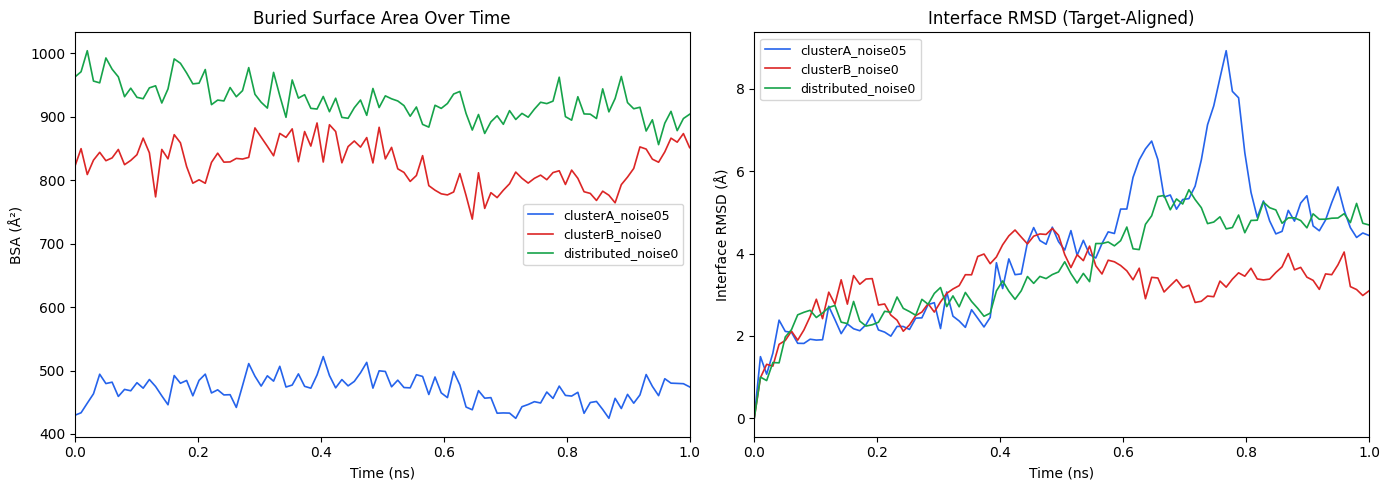


Sanity checks:
  clusterA_noise05: BSA mean=469.6 A² (expect 400-1200)
  clusterB_noise0: BSA mean=824.8 A² (expect 400-1200)
  distributed_noise0: BSA mean=925.2 A² (expect 400-1200)
  clusterA_noise05: iRMSD mean=3.98 A (expect 1-5)
  clusterB_noise0: iRMSD mean=3.23 A (expect 1-5)
  distributed_noise0: iRMSD mean=3.64 A (expect 1-5)


In [9]:
# ============================================================
# Cell 8 — Visualization
# ============================================================
import matplotlib.pyplot as plt

colors = {
    'clusterA': '#2563eb',
    'distributed': '#16a34a',
    'clusterB': '#dc2626'
}

def get_color(name):
    if 'clusterA' in name: return colors['clusterA']
    if 'clusterB' in name: return colors['clusterB']
    if 'distributed' in name: return colors['distributed']
    return '#666'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, g in all_bsa_df.groupby('design_name'):
    short = name.split('__')[0].replace('len70_', '')
    ax.plot(g['time_ns'], g['bsa_A2'], label=short, color=get_color(name), linewidth=1.2)
ax.set_xlabel('Time (ns)'); ax.set_ylabel('BSA (Å²)')
ax.set_title('Buried Surface Area Over Time')
ax.legend(fontsize=9); ax.set_xlim(0, 1)

ax = axes[1]
for name, g in all_irmsd_df.groupby('design_name'):
    short = name.split('__')[0].replace('len70_', '')
    ax.plot(g['time_ns'], g['interface_rmsd_A'], label=short, color=get_color(name), linewidth=1.2)
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Interface RMSD (Å)')
ax.set_title('Interface RMSD (Target-Aligned)')
ax.legend(fontsize=9); ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bsa_and_interface_rmsd.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nSanity checks:")
for name, g in all_bsa_df.groupby('design_name'):
    short = name.split('__')[0].replace('len70_', '')
    print(f"  {short}: BSA mean={g['bsa_A2'].mean():.1f} A² (expect 400-1200)")
for name, g in all_irmsd_df.groupby('design_name'):
    short = name.split('__')[0].replace('len70_', '')
    print(f"  {short}: iRMSD mean={g['interface_rmsd_A'].mean():.2f} A (expect 1-5)")


In [ ]:
row = manifest[manifest['design_name'].str.contains('clusterA')].iloc[0]
print(Path(row['traj_dcd']).exists(), row['traj_dcd'])

True /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/production.dcd
